In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from scipy import stats

pd.set_option("display.float_format", "{:.4f}".format)
DATA_DIR = "../data"

In [2]:
#Load dataset
combined = pd.read_csv(
    os.path.join(DATA_DIR, "combined.csv"),
    parse_dates=["HourDK"]
).sort_values("HourDK").reset_index(drop=True)

print(f"Rows: {len(combined)}")
print(f"Range: {combined['HourDK'].min()} → {combined['HourDK'].max()}")
combined.head()

Rows: 2159
Range: 2025-07-02 01:00:00 → 2025-09-29 23:00:00


,HourDK,SpotPriceEUR,OffshoreWind,OnshoreWind,Solar,GrossConsumptionMWh,TotalWind,SpotPriceEUR_diff,TotalWind_diff,OffshoreWind_diff,OnshoreWind_diff,Solar_diff
0,2025-07-02 01:00:00,102.7000,393.9523,340.6398,0.4309,2234.6694,734.5921,-16.5900,74.7066,69.6704,5.0363,-0.1031
1,2025-07-02 02:00:00,92.5400,430.9745,386.2130,0.3986,2306.8370,817.1875,-10.1600,82.5954,37.0222,45.5732,-0.0324
2,2025-07-02 03:00:00,92.0800,321.3976,423.6959,0.5746,2207.1964,745.0935,-0.4600,-72.0940,-109.5769,37.4829,0.1761
3,2025-07-02 04:00:00,91.7100,178.6053,309.7509,2.9238,2142.2299,488.3563,-0.3700,-256.7372,-142.7922,-113.9450,2.3491
4,2025-07-02 05:00:00,100.5500,247.7690,276.0343,51.1870,2149.4432,523.8033,8.8400,35.4470,69.1637,-33.7167,48.2632


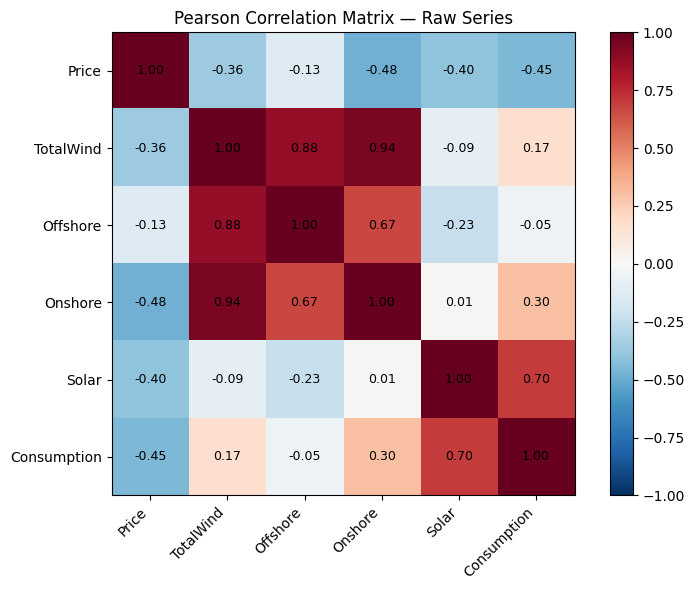


Correlation with Spot Price:
OnshoreWind           -0.4770
GrossConsumptionMWh   -0.4470
Solar                 -0.4049
TotalWind             -0.3632
OffshoreWind          -0.1261
SpotPriceEUR           1.0000
Name: SpotPriceEUR, dtype: float64


In [3]:
#Cor matrix
# Pearson correlation between all key variables.
# This is the starting point — a snapshot of the entire period.
# Important: correlation says nothing about causation or direction.

cols = ["SpotPriceEUR", "TotalWind", "OffshoreWind", "OnshoreWind", "Solar", "GrossConsumptionMWh"]
corr_matrix = combined[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(["Price", "TotalWind", "Offshore", "Onshore", "Solar", "Consumption"], rotation=45, ha="right")
ax.set_yticklabels(["Price", "TotalWind", "Offshore", "Onshore", "Solar", "Consumption"])

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Pearson Correlation Matrix — Raw Series")
plt.tight_layout()
plt.show()

print("\nCorrelation with Spot Price:")
print(corr_matrix["SpotPriceEUR"].sort_values())

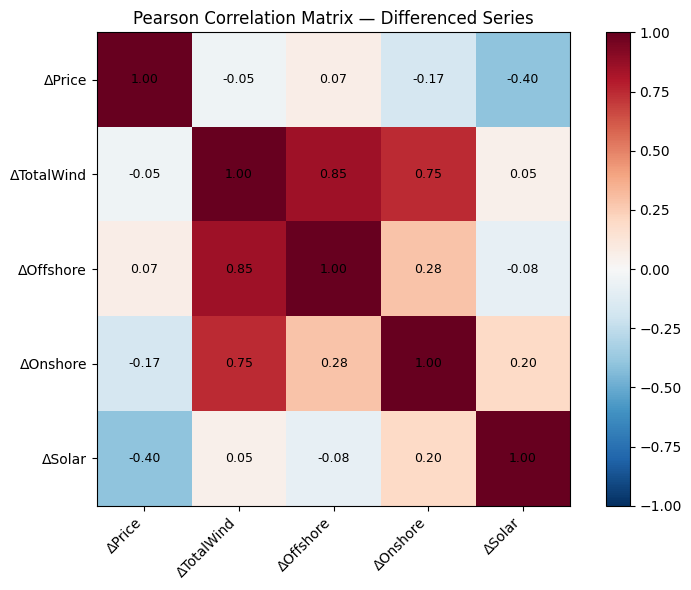


Correlation with ΔSpot Price:
Solar_diff          -0.4038
OnshoreWind_diff    -0.1676
TotalWind_diff      -0.0452
OffshoreWind_diff    0.0676
SpotPriceEUR_diff    1.0000
Name: SpotPriceEUR_diff, dtype: float64


In [4]:
#Cor on series
# We repeat the correlation matrix on differenced series.
# Differenced series removes trend effects so we see short-term co-movement.
# Compare this to the raw matrix above — differences tell a story.

diff_cols = ["SpotPriceEUR_diff", "TotalWind_diff", "OffshoreWind_diff", "OnshoreWind_diff", "Solar_diff"]
corr_diff = combined[diff_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_diff, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = ["ΔPrice", "ΔTotalWind", "ΔOffshore", "ΔOnshore", "ΔSolar"]
ax.set_xticks(range(len(diff_cols)))
ax.set_yticks(range(len(diff_cols)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(diff_cols)):
    for j in range(len(diff_cols)):
        ax.text(j, i, f"{corr_diff.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Pearson Correlation Matrix — Differenced Series")
plt.tight_layout()
plt.show()

print("\nCorrelation with ΔSpot Price:")
print(corr_diff["SpotPriceEUR_diff"].sort_values())

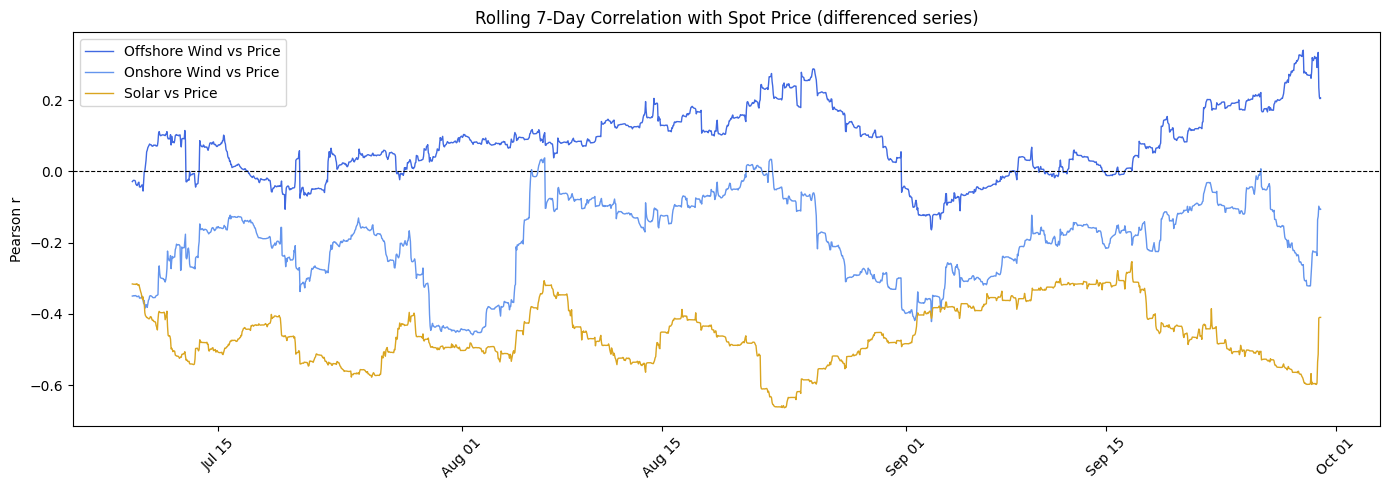

In [5]:
#Cor over time
# Static correlation hides how the relationship CHANGES over time.
# Rolling correlation shows whether wind/price correlation is stable
# or whether it strengthens/weakens across the 90-day window.
# Window = 7*24 = one week of hourly observations.

WINDOW = 7 * 24

rolling_offshore = combined["SpotPriceEUR_diff"].rolling(WINDOW).corr(combined["OffshoreWind_diff"])
rolling_onshore  = combined["SpotPriceEUR_diff"].rolling(WINDOW).corr(combined["OnshoreWind_diff"])
rolling_solar    = combined["SpotPriceEUR_diff"].rolling(WINDOW).corr(combined["Solar_diff"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(combined["HourDK"], rolling_offshore, label="Offshore Wind vs Price", linewidth=1.0, color="royalblue")
ax.plot(combined["HourDK"], rolling_onshore,  label="Onshore Wind vs Price",  linewidth=1.0, color="cornflowerblue")
ax.plot(combined["HourDK"], rolling_solar,    label="Solar vs Price",          linewidth=1.0, color="goldenrod")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 7-Day Correlation with Spot Price (differenced series)")
ax.set_ylabel("Pearson r")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

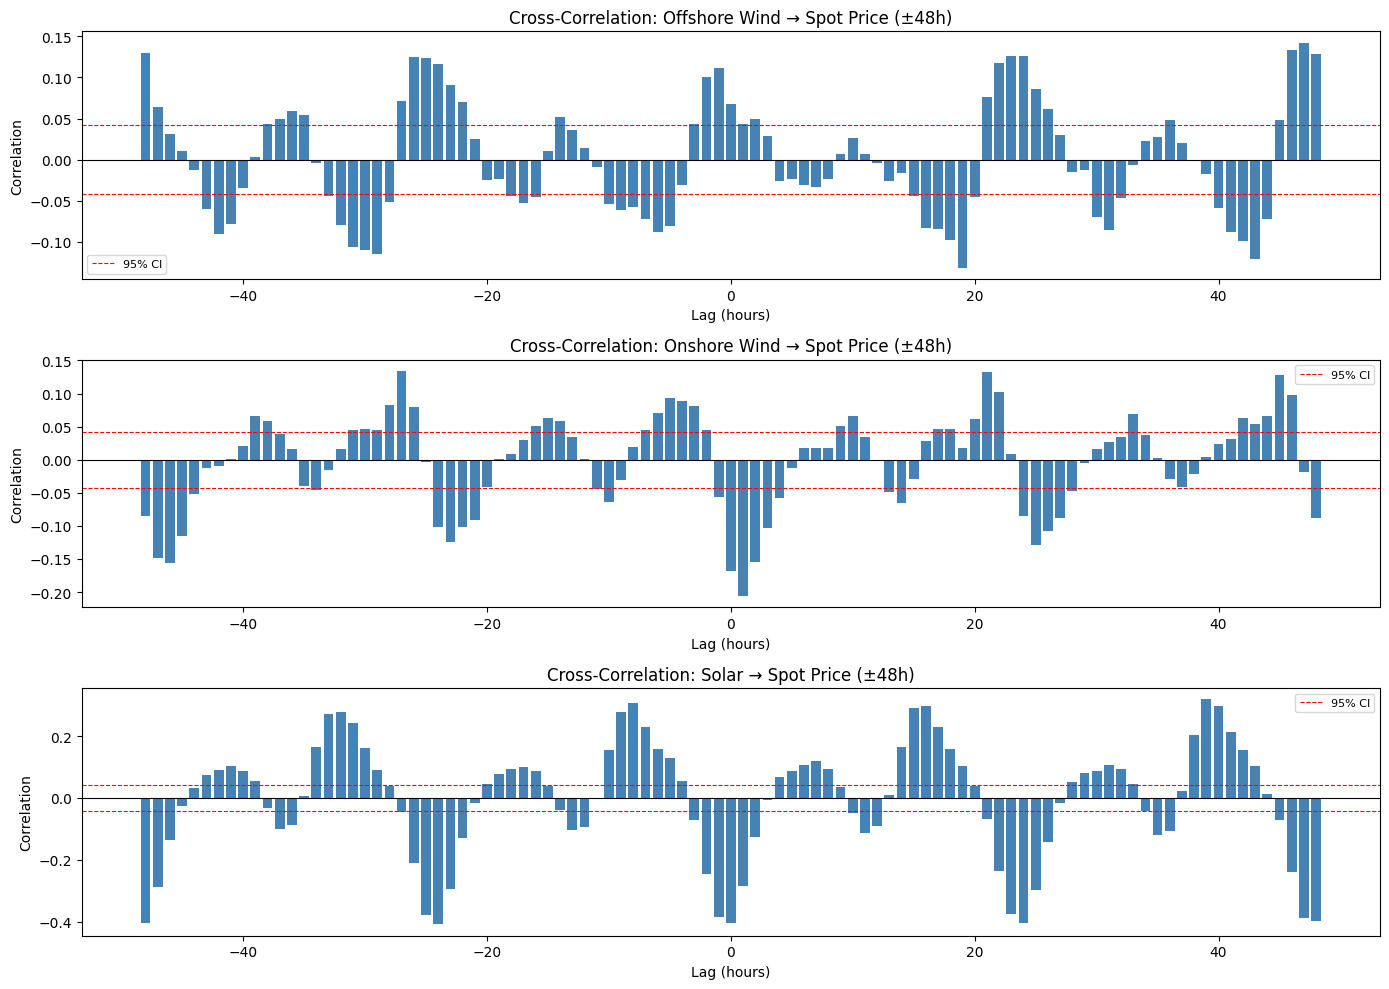

In [6]:
#Cor with lag
# Cross-correlation asks: does wind at time T correlate with price at time T+k?
# A peak at lag k > 0 means wind LEADS price by k hours — a hint at causality.
# A peak at lag k < 0 means price leads wind.
# A peak at lag 0 means they move together simultaneously.

def cross_correlation_plot(x: pd.Series, y: pd.Series, max_lag: int, title: str, ax):
    lags = range(-max_lag, max_lag + 1)
    corrs = [x.corr(y.shift(lag)) for lag in lags]
    ax.bar(lags, corrs, color="steelblue", width=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline( 1.96/np.sqrt(len(x)), color="red", linewidth=0.8, linestyle="--", label="95% CI")
    ax.axhline(-1.96/np.sqrt(len(x)), color="red", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("Correlation")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

cross_correlation_plot(
    combined["OffshoreWind_diff"],
    combined["SpotPriceEUR_diff"],
    max_lag=48,
    title="Cross-Correlation: Offshore Wind → Spot Price (±48h)",
    ax=axes[0]
)
cross_correlation_plot(
    combined["OnshoreWind_diff"],
    combined["SpotPriceEUR_diff"],
    max_lag=48,
    title="Cross-Correlation: Onshore Wind → Spot Price (±48h)",
    ax=axes[1]
)
cross_correlation_plot(
    combined["Solar_diff"],
    combined["SpotPriceEUR_diff"],
    max_lag=48,
    title="Cross-Correlation: Solar → Spot Price (±48h)",
    ax=axes[2]
)

plt.tight_layout()
plt.show()

=== Spurious Correlation Demo ===
Correlation between spot price and pure random noise: r = -0.0040, p = 0.8539

This illustrates why a statistically significant correlation can still be meaningless.
Notebook 04 uses Granger causality to go beyond correlation.


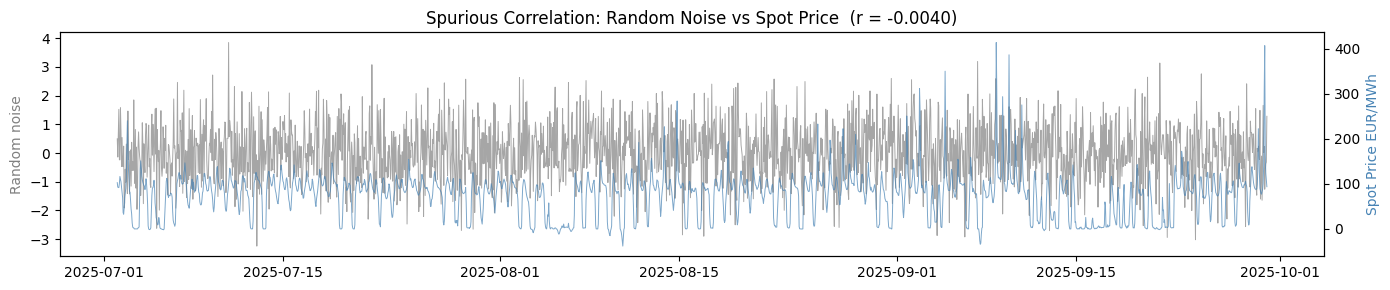

In [7]:
# This cell deliberately demonstrates a spurious correlation —
# an important statistical honesty point for the README and presentation.
#
# We correlate spot price with a completely random series.
# Over 90 days of hourly data, random chance will produce
# non-trivial correlations that mean absolutely nothing.
# This is why correlation alone is never enough.

np.random.seed(42)
random_series = pd.Series(np.random.randn(len(combined)))
spurious_r, spurious_p = stats.pearsonr(
    combined["SpotPriceEUR"].dropna(),
    random_series[:len(combined["SpotPriceEUR"].dropna())]
)

print("=== Spurious Correlation Demo ===")
print(f"Correlation between spot price and pure random noise: r = {spurious_r:.4f}, p = {spurious_p:.4f}")
print()
print("This illustrates why a statistically significant correlation can still be meaningless.")
print("Notebook 04 uses Granger causality to go beyond correlation.")

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(combined["HourDK"], random_series[:len(combined)], linewidth=0.7, color="grey", alpha=0.7)
ax2 = ax.twinx()
ax2.plot(combined["HourDK"], combined["SpotPriceEUR"], linewidth=0.7, color="steelblue", alpha=0.7)
ax.set_title(f"Spurious Correlation: Random Noise vs Spot Price  (r = {spurious_r:.4f})")
ax.set_ylabel("Random noise", color="grey")
ax2.set_ylabel("Spot Price EUR/MWh", color="steelblue")
plt.tight_layout()
plt.show()

In [8]:
#Summary
# Clean summary of all correlations with spot price for the README.

summary = pd.DataFrame({
    "Variable": ["Offshore Wind", "Onshore Wind", "Solar", "Gross Consumption"],
    "Raw r":  [
        combined["SpotPriceEUR"].corr(combined["OffshoreWind"]),
        combined["SpotPriceEUR"].corr(combined["OnshoreWind"]),
        combined["SpotPriceEUR"].corr(combined["Solar"]),
        combined["SpotPriceEUR"].corr(combined["GrossConsumptionMWh"]),
    ],
    "Differenced r": [
        combined["SpotPriceEUR_diff"].corr(combined["OffshoreWind_diff"]),
        combined["SpotPriceEUR_diff"].corr(combined["OnshoreWind_diff"]),
        combined["SpotPriceEUR_diff"].corr(combined["Solar_diff"]),
        combined["SpotPriceEUR_diff"].corr(combined["GrossConsumptionMWh"].diff()),
    ]
})

print(summary.to_string(index=False))

         Variable   Raw r  Differenced r
    Offshore Wind -0.1261         0.0676
     Onshore Wind -0.4770        -0.1676
            Solar -0.4049        -0.4038
Gross Consumption -0.4470        -0.2646
